In [1]:
import pandas as pd
import numpy as np
from dowhy import CausalModel
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from econml.dml import CausalForestDML
from econml.dr import DRLearner
import matplotlib.pyplot as plt
from dowhy import CausalModel, gcm
import graphviz
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import RobustScaler


/Users/mkhan04/Desktop/ci4security/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("alerts_with_category_with_apk_size_updated.csv")

# Drop obfuscated
df = df[~df["code_location"].str.contains("obfuscated", case=False, na=False)].copy()

# Core variables
df["verdict"] = df["verdict"].astype(int)
df["is_third_party"] = (~df["code_location"].isin(["developer_written"])).astype(int)

# Normalize apk_size
scaler = RobustScaler()
df["apk_size_scaled"] = scaler.fit_transform(df[["apk_size"]])
df["code_location"].value_counts()


code_location
Utilities            3039
others               1341
developer_written     511
Android               494
SocialMedia           180
Analytics              34
Cloud                  13
Name: count, dtype: int64

In [3]:
download_order = [
    "<100", "100-500", "500-1k", "1k-5k", "5k-10k", "10k-50k",
    "50k-100k", "100k-500k", "500k-1M", "1M-5M", ">5M"
]
download_map = {cat: i for i, cat in enumerate(download_order)}
df["app_popularity_encoded"] = df["app_popularity"].map(download_map)

# Library grouping (library type from code_location)
small_libs = ["SocialMedia", "Analytics", "Cloud"]
df["lib_grouped"] = df["code_location"].replace(small_libs, "Small_Libraries")
df.loc[df["lib_grouped"] == "developer_written", "lib_grouped"] = "App_Source_Code"  

df["lib_grouped"].value_counts()


lib_grouped
Utilities          3039
others             1341
App_Source_Code     511
Android             494
Small_Libraries     227
Name: count, dtype: int64

In [4]:
df.head()


,alert_description,verdict,artifact_location,app_package_name,version_code,app_popularity,sast_tool_name,code_location,3rd_party_library_name,apk_size,is_third_party,apk_size_scaled,app_popularity_encoded,lib_grouped
0,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",1,com/applovin/impl/sdk/utils/m.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,others,unknown,14562465,1,0.015672,0,others
1,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",1,com/applovin/impl/sdk/utils/StringUtils.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,others,unknown,14562465,1,0.015672,0,others
2,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",1,com/google/android/gms/internal/ads/zzcgg.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,Android,com.google.android.gms::play-services-ads-base,14562465,1,0.015672,0,Android
3,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",1,com/google/android/gms/internal/ads/zzcgg.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,Android,com.google.android.gms::play-services-ads-base,14562465,1,0.015672,0,Android
4,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",1,com/google/android/gms/internal/zzaiy.java,aplus.droitfiscal,37,5k-10k,CogniCrypt,Android,com.google.android.gms::play-services-clearcut,3041670,1,-0.674171,4,Android


In [5]:
libs = list(df["lib_grouped"].unique())
# Ensure baseline is first
if "App_Source_Code" in libs:
    libs = ["App_Source_Code"] + [l for l in libs if l != "App_Source_Code"]
else:
    raise ValueError("App_Source_Code not found in lib_grouped; check preprocessing.")

# Categorical encoding with a fixed order so 0 = App_Source_Code
lib_cat = pd.Categorical(df["lib_grouped"], categories=libs, ordered=True)
df["lib_treat_code"] = lib_cat.codes   # 0, 1, 2, ...

print("Treatment levels (code -> label):")
for k, name in enumerate(libs):
    print(f"{k}: {name}")
print()

# Outcome and treatment arrays
Y = df["verdict"].values            # outcome
T = df["lib_treat_code"].values     # discrete treatment (multi-class)

# Features (X) that capture effect heterogeneity
# Confounders (W) from your causal graph: apk_size_scaled, app_popularity_encoded
# Here we use the same for both X and W; you can add more if justified.
feature_cols = ["apk_size_scaled", "app_popularity_encoded"]
X = df[feature_cols].values
W = X.copy()

# Drop rows with missing popularity (if any)
mask = ~np.isnan(X).any(axis=1)
Y = Y[mask]
T = T[mask]
X = X[mask]
W = W[mask]

Treatment levels (code -> label):
0: App_Source_Code
1: others
2: Android
3: Utilities
4: Small_Libraries



In [6]:
dr = DRLearner(model_regression=RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=10,
        random_state=42
    ),
    model_propensity=RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=10,
        random_state=42
    ),
    model_final=RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=5,
        random_state=42
    ),
    # discrete_treatment=True,
    categories='auto',   # use the integer codes as discrete treatments
    random_state=42
)

dr.fit(Y, T, X=X, W=W)

print("Fitted DRLearner with discrete multi-valued treatment.\n")

Fitted DRLearner with discrete multi-valued treatment.



In [7]:
results = []

n = len(Y)
baseline_code = 0  # by construction: 0 = App_Source_Code

for k, lib_name in enumerate(libs):
    if k == baseline_code:
        continue  # skip baseline; effect vs itself is 0

    # For each sample, we simulate: T0 = baseline, T1 = this library
    T0 = np.full(n, baseline_code, dtype=int)
    T1 = np.full(n, k, dtype=int)

    # Heterogeneous treatment effects tau_i = Y(lib=k) - Y(lib=baseline) | X_i
    tau = dr.effect(X=X, T0=T0, T1=T1)
    tau_mean = float(np.mean(tau))
    tau_std = float(np.std(tau))

    results.append({
        "library": lib_name,
        "ATE_vs_App_Source_Code": tau_mean,
        "ATE_std": tau_std,
        "n_samples": n
    })

results_df = pd.DataFrame(results).sort_values("ATE_vs_App_Source_Code")
print("Estimated causal effect of each library type vs App_Source_Code:")
print(results_df, "\n")


Estimated causal effect of each library type vs App_Source_Code:
           library  ATE_vs_App_Source_Code     ATE_std  n_samples
2        Utilities              -60.912344  658.792580       5612
0           others              -60.523561  658.765657       5612
1          Android              -60.254883  658.783630       5612
3  Small_Libraries              -42.536961  700.403035       5612 



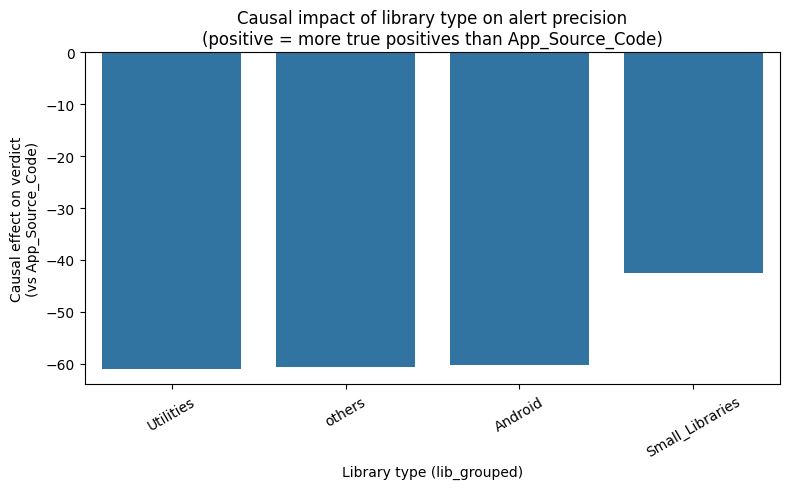

Library 'Utilities' reduces precision relative to App_Source_Code: -60.912 (std 658.793)
Library 'others' reduces precision relative to App_Source_Code: -60.524 (std 658.766)
Library 'Android' reduces precision relative to App_Source_Code: -60.255 (std 658.784)
Library 'Small_Libraries' reduces precision relative to App_Source_Code: -42.537 (std 700.403)


In [8]:
plt.figure(figsize=(8, 5))
sns.barplot(
    x="library",
    y="ATE_vs_App_Source_Code",
    data=results_df,
    capsize=0.2
)
plt.axhline(0, color="gray", linestyle="--")
plt.ylabel("Causal effect on verdict\n(vs App_Source_Code)")
plt.xlabel("Library type (lib_grouped)")
plt.title("Causal impact of library type on alert precision\n(positive = more true positives than App_Source_Code)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Optional: textual interpretation
for _, row in results_df.iterrows():
    direction = "reduces" if row["ATE_vs_App_Source_Code"] < 0 else "improves"
    print(
        f"Library '{row['library']}' {direction} precision relative to App_Source_Code: "
        f"{row['ATE_vs_App_Source_Code']:.3f} (std {row['ATE_std']:.3f})"
    )
